In [13]:
# Import the packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import mutual_info_score
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score, roc_curve

In [14]:
df = pd.read_csv("course_lead_scoring.csv")
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


##### Data preperation

In [15]:
# Check if the missing values are presented in the features
# print(df.isna().sum())

# If there are missing values:
# For categorical features, replace them with 'NA'
cat = df.select_dtypes(include='object').columns
df[cat] = df[cat].fillna('NA')

# For numerical features, replace with with 0.0
cat = df.select_dtypes(include='number').columns
df[cat] = df[cat].fillna(0.0)

print(df.isna().sum())

lead_source                 0
industry                    0
number_of_courses_viewed    0
annual_income               0
employment_status           0
location                    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64


In [16]:
# Features and targets
X = df.drop(columns='converted')
y = df['converted']

# First 60% train and 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=1
)

# After that 20% validation and 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=1
)

print(len(X_train), len(X_val), len(X_test))

877 292 293


##### Question 1: ROC AUC feature importance

In [ ]:
# Get only the numeric columns for the exercise and delete the target column converted
num_col = df.select_dtypes(include='number').columns
num_col = num_col.drop('converted')
num_col

Index(['number_of_courses_viewed', 'annual_income', 'interaction_count',
       'lead_score'],
      dtype='object')

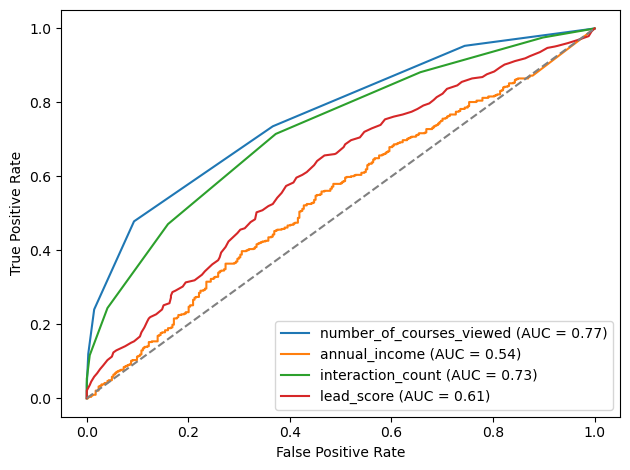

In [ ]:
# Compute the AUC for every numeric column
for c in num_col:
    scores = X_train[c]
    auc = roc_auc_score(y_train, scores)
    if auc < 0.5:              
        scores = -scores
        auc = roc_auc_score(y_train, scores)

    fpr, tpr, thresholds = roc_curve(y_train, scores)
    plt.plot(fpr, tpr, label=f"{c} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], "--", color="grey")   
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

# The answer is number_of_courses_viewed

##### Question 2: Training the model

In [36]:
# Create a dictionary for every row
train_dicts = X_train.to_dict(orient='records')
val_dicts   = X_val.to_dict(orient='records')

# One-hot encoding: fit on train, transform on val
dv = DictVectorizer(sparse=False)
X_train_encoded = dv.fit_transform(train_dicts)
X_val_encoded   = dv.transform(val_dicts)

# Train the logistic regression
model = LogisticRegression(
    #solver='liblinear',
    C=1.0,
    max_iter=1000
)
model.fit(X_train_encoded, y_train)

# predict_proba returns probabilities; [:, 1] takes the positive class
y_scores = model.predict_proba(X_val_encoded)[:, 1]
original_score = roc_auc_score(y_val, y_scores)
auc_score = round(original_score, 3)

print(auc_score)

# So the answer is around 0,92 because he doesn't use the liblinear in the solution

0.905


c:\Users\WilliamvanderAa\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


##### Question 3: Precision and Recall

In [43]:
# Use linspace to create the steps between 0.0 and 1.0
def confusion_matrix_dataframe(y_val, y_pred):
    scores = []

    thresholds = np.linspace(0, 1, 101)

    # Calculate the different confusions for every threshold and add them in a dataframe
    for t in thresholds:
        actual_positive = (y_val == 1)
        actual_negative = (y_val == 0)

        predict_positive = (y_pred >= t)
        predict_negative = (y_pred < t)

        tp = (predict_positive & actual_positive).sum()
        tn = (predict_negative & actual_negative).sum()

        fp = (predict_positive & actual_negative).sum()
        fn = (predict_negative & actual_positive).sum()

        scores.append((t, tp, fp, fn, tn))

    columns = ['threshold', 'tp', 'fp', 'fn', 'tn']
    df_scores = pd.DataFrame(scores, columns=columns)

    return df_scores

In [ ]:
# Use the function above to calculate the df_scores
df_scores = confusion_matrix_dataframe(y_val, y_scores)
df_scores[::10]

,threshold,tp,fp,fn,tn
0,0.0,192,100,0,0
10,0.1,189,73,3,27
20,0.2,186,57,6,43
30,0.3,181,40,11,60
40,0.4,175,34,17,66
50,0.5,170,27,22,73
60,0.6,164,19,28,81
70,0.7,150,11,42,89
80,0.8,133,6,59,94
90,0.9,104,4,88,96


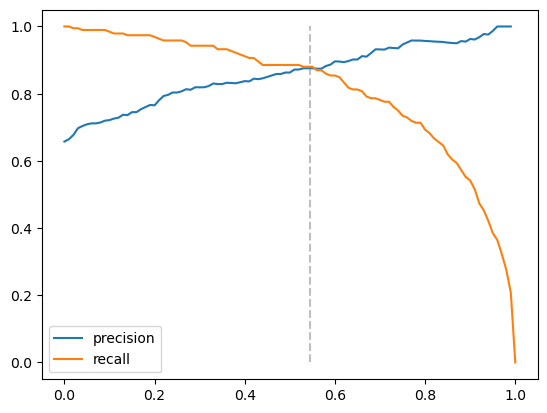

In [45]:
# Use the df_scores to get the precision and recall
df_scores['p'] = df_scores.tp / (df_scores.tp + df_scores.fp)
df_scores['r'] = df_scores.tp / (df_scores.tp + df_scores.fn)

plt.plot(df_scores.threshold, df_scores.p, label='precision')
plt.plot(df_scores.threshold, df_scores.r, label='recall')

plt.vlines(0.545, 0, 1, color='grey', linestyle='--', alpha=0.5)

plt.legend()
plt.show()

# The answer on the intersect is around 0.545

##### Question 4: F1 score

In [47]:
thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    f_one = 2 * ((df_scores['p'] * df_scores['r']) / (df_scores['p'] + df_scores['r']))
    print(f_one)


0      0.793388
1      0.798337
2      0.805907
3      0.819742
4      0.822511
         ...   
96     0.534351
97     0.488189
98     0.432653
99     0.344828
100         NaN
Length: 101, dtype: float64
0      0.793388
1      0.798337
2      0.805907
3      0.819742
4      0.822511
         ...   
96     0.534351
97     0.488189
98     0.432653
99     0.344828
100         NaN
Length: 101, dtype: float64
0      0.793388
1      0.798337
2      0.805907
3      0.819742
4      0.822511
         ...   
96     0.534351
97     0.488189
98     0.432653
99     0.344828
100         NaN
Length: 101, dtype: float64
0      0.793388
1      0.798337
2      0.805907
3      0.819742
4      0.822511
         ...   
96     0.534351
97     0.488189
98     0.432653
99     0.344828
100         NaN
Length: 101, dtype: float64
0      0.793388
1      0.798337
2      0.805907
3      0.819742
4      0.822511
         ...   
96     0.534351
97     0.488189
98     0.432653
99     0.344828
100         NaN
Length: 